# Laboratorio 2 — Números (pseudo)aleatorios y Generación de Variables Aleatorias

**Universidad de los Llanos** · Facultad de Ciencias Básicas e Ingenierías · Programa de Ingeniería de Sistemas

**Curso:** Simulación Computacional · **Práctica N.º 02**

**Estudiante:** Miguel Ángel Rincón Morales — Cód. 160005038

---

Este *notebook* desarrolla las cuatro secciones del procedimiento de la guía:

| Sección | Contenido |
|---|---|
| **5.1** | Generación de números (pseudo)aleatorios: MidSquare, generador congruencial mixto (GLC), Lagged-Fibonacci y Shift-Register; tamaño de ciclo, prueba de uniformidad ($\chi^2$) y prueba de aleatoriedad (rachas). |
| **5.2** | Uso de números aleatorios para evaluar integrales (método Monte Carlo, ejercicios 3 a 9 del Cap. 3 de [Ross99]). |
| **5.3** | Generación de variables aleatorias discretas por transformada inversa y por composición. |
| **5.4** | Simulación *ad hoc* del Laboratorio 1 usando tiempos entre llegadas Poisson($\lambda=10$) y tiempos de servicio Binomial($n=10, p=0.40$). |

**Referencias:** [Ross99] Ross, S. *Simulación*, 2.ª ed., Pearson, 1999 (Caps. 3 y 4) · [Mancilla2000] Mancilla Herrera, A. M. *Números aleatorios. Historia, teoría y aplicaciones*, Ingeniería y Desarrollo, n.º 8, 2000 · [Banks1998] Banks, J. *Handbook of Simulation*, Wiley, 1998 (Cap. 1).

---
# 5.1. Generación de números (pseudo)aleatorios

## 5.1.1. MidSquare

El método de los **cuadrados medios** (*Middle-Square*, von Neumann) parte de una semilla $X_0$ de $d$ dígitos y construye la sucesión

$$X_{i+1} = \text{dígitos centrales}\big(X_i^2\big), \qquad u_{i+1} = \frac{X_{i+1}}{10^{\,d}}$$

Se genera una secuencia de $n = 100$ números para cada una de las cinco semillas pedidas en la guía.

In [1]:
import pandas as pd

def midsquare_generator(seed, n):
    """
    Genera una secuencia de números pseudoaleatorios usando el método
    de MidSquare (Cuadrados Medios).
    """
    d = len(str(seed))
    X = seed
    X_list = []
    u_list = []

    for _ in range(n):
        X2 = X ** 2
        X2_str = str(X2).zfill(2 * d)
        start = (2 * d - d) // 2
        mid_str = X2_str[start:start + d]
        X = int(mid_str)

        X_list.append(X)
        u_list.append(X / (10 ** d))

    return X_list, u_list


# Semillas del punto 5.1.1
seeds = {
    'Semilla a (1931)': 1931,
    'Semilla b (675248)': 675248,
    'Semilla c (4567)': 4567,
    'Semilla d (12122)': 12122,
    'Semilla e (7179345)': 7179345
}

n = 100

# Construimos un diccionario con los u_i de cada semilla
data = {'Iteración': list(range(1, n + 1))}

for nombre, seed in seeds.items():
    _, u_seq = midsquare_generator(seed, n)
    data[nombre] = [round(u, 4) for u in u_seq]

# Tabla única con todas las secuencias
tabla_midsquare = pd.DataFrame(data)
tabla_midsquare

,Iteración,Semilla a (1931),Semilla b (675248),Semilla c (4567),Semilla d (12122),Semilla e (7179345)
0,1,0.7287,0.9599,0.8574,0.4694,0.4299
1,2,0.1003,0.3331,0.5134,0.0355,0.8537
2,3,0.0060,0.9816,0.3579,0.1261,0.8631
3,4,0.0036,0.5248,0.8092,0.5899,0.9566
4,5,0.0012,0.4329,0.4804,0.7935,0.1371
...,...,...,...,...,...,...
95,96,0.0000,0.6645,0.8100,0.0000,0.6482
96,97,0.0000,0.6227,0.6100,0.0000,0.1441
97,98,0.0000,0.7740,0.2100,0.0000,0.7514
98,99,0.0000,0.0311,0.4100,0.0000,0.5749


Ya en la tabla se aprecia el problema clásico del método: las semillas **a (1931)** y **d (12122)** colapsan a
$u_i = 0$ y se quedan ahí, es decir, la sucesión *degenera* antes de completar los 100 valores.
El tamaño de ciclo se cuantifica formalmente en el punto 5.1.4.

## 5.1.2. Generador congruencial mixto (GLC)

$$X_{i+1} = (a\,X_i + c) \bmod m, \qquad u_{i+1} = \frac{X_{i+1}}{m}$$

Se generan $n = 100$ números para los cinco juegos de parámetros $(X_0, a, c, m)$ de la guía.

In [2]:
import pandas as pd

def lcg_generator(X0, a, c, m, n):
    X = X0
    X_list = []
    u_list = []

    for _ in range(n):
        X = (a * X + c) % m
        X_list.append(X)
        u_list.append(X / m)

    return X_list, u_list


# Parámetros
parametros = {
    'a) X0=127,a=115,c=0,m=128':        {'X0': 127,      'a': 115,          'c': 0,  'm': 128},
    'b) X0=43,a=25,c=5,m=48':           {'X0': 43,       'a': 25,           'c': 5,  'm': 48},
    'c) X0=13,a=16807,c=0,m=2^31-1':    {'X0': 13,       'a': 16807,        'c': 0,  'm': 2**31 - 1},
    'd) X0=29022024,a=25214903917,c=11,m=2^48': {'X0': 29022024, 'a': 25214903917, 'c': 11, 'm': 2**48},
    'e) X0=3,a=5,c=7,m=200':            {'X0': 3,        'a': 5,            'c': 7,  'm': 200},
}

n = 100

# Construimos la tabla
data = {'Iteración': list(range(1, n + 1))}
resultados = {}  # guardamos también los X_i por si se necesitan después (ciclo, etc.)

for nombre, p in parametros.items():
    X_seq, u_seq = lcg_generator(p['X0'], p['a'], p['c'], p['m'], n)
    resultados[nombre] = {'X': X_seq, 'u': u_seq, 'params': p}
    data[nombre] = [round(u, 4) for u in u_seq]

tabla_glc = pd.DataFrame(data)


tabla_glc

,Iteración,"a) X0=127,a=115,c=0,m=128","b) X0=43,a=25,c=5,m=48","c) X0=13,a=16807,c=0,m=2^31-1","d) X0=29022024,a=25214903917,c=11,m=2^48","e) X0=3,a=5,c=7,m=200"
0,1,0.1016,0.5000,0.0001,0.8316,0.110
1,2,0.6797,0.6042,0.7100,0.5264,0.585
2,3,0.1641,0.2083,0.8229,0.5038,0.960
3,4,0.8672,0.3125,0.9625,0.0123,0.835
4,5,0.7266,0.9167,0.9260,0.9113,0.210
...,...,...,...,...,...,...
95,96,0.9922,0.8958,0.9978,0.5622,0.335
96,97,0.1016,0.5000,0.3571,0.1599,0.710
97,98,0.6797,0.6042,0.9396,0.9668,0.585
98,99,0.1641,0.2083,0.5011,0.8683,0.960


## 5.1.3. Otros generadores de números aleatorios

De los métodos descritos en [Mancilla2000] se implementan dos:

**Lagged-Fibonacci:** $\;X_i = (X_{i-j} + X_{i-k}) \bmod m$, con $j < k$ y $k$ semillas iniciales.
Parámetros escogidos: $j = 5$, $k = 17$, $m = 2^{31}$.

**Shift-Register (LFSR):** $\;b_i = b_{i-p} \oplus b_{i-q}$ sobre una cadena de bits; cada $n_b$ bits consecutivos
forman un entero. Parámetros escogidos: $p = 7$, $q = 3$, $n_b = 10$ bits por valor.

In [3]:
import pandas as pd

def lagged_fibonacci_generator(seeds, j, k, m, n, op='+'):
    assert len(seeds) >= k, "Se necesitan al menos k semillas"
    X = list(seeds)

    for i in range(k, k + n):
        if op == '+':
            X.append((X[i - j] + X[i - k]) % m)
        else:
            X.append((X[i - j] * X[i - k]) % m)

    X_generados = X[k:k + n]
    u_list = [x / m for x in X_generados]
    return X_generados, u_list


# Parámetros de ejemplo
j_lf, k_lf, m_lf = 5, 17, 2**31
seeds_lf = [1931, 675248, 4567, 12122, 7179345,
            2391, 8842, 173, 9284, 55321,
            883, 20194, 671, 3348, 9021,
            4471, 12]

n = 100
X_lf, u_lf = lagged_fibonacci_generator(seeds_lf, j_lf, k_lf, m_lf, n, op='+')

def shift_register_generator(seed_bits, p, q, n_bits_out, n):
    bits = list(seed_bits)
    total_bits_needed = n * n_bits_out

    while len(bits) < len(seed_bits) + total_bits_needed:
        i = len(bits)
        nuevo_bit = bits[i - p] ^ bits[i - q]
        bits.append(nuevo_bit)

    # Descartamos los bits semilla y agrupamos el resto en bloques
    bits_generados = bits[len(seed_bits):]
    X_list = []
    for i in range(n):
        bloque = bits_generados[i * n_bits_out:(i + 1) * n_bits_out]
        valor = int(''.join(map(str, bloque)), 2)
        X_list.append(valor)

    max_val = 2 ** n_bits_out - 1
    u_list = [x / max_val for x in X_list]
    return X_list, u_list


# Parámetros de ejemplo para Shift-Register
p_sr, q_sr = 7, 3
n_bits_out = 10
seed_bits_sr = [1, 0, 1, 1, 0, 0, 1]  # semilla binaria, longitud = p_sr


X_sr, u_sr = shift_register_generator(seed_bits_sr, p_sr, q_sr, n_bits_out, n)


data = {
    'Iteración': list(range(1, n + 1)),
    'Lagged-Fibonacci (u_i)': [round(u, 4) for u in u_lf],
    'Shift-Register (u_i)': [round(u, 4) for u in u_sr],
}

tabla_531 = pd.DataFrame(data)

tabla_531

,Iteración,Lagged-Fibonacci (u_i),Shift-Register (u_i)
0,1,0.0000,0.5132
1,2,0.0003,0.6823
2,3,0.0000,0.1955
3,4,0.0000,0.5044
4,5,0.0033,0.6031
...,...,...,...
95,96,0.5858,0.9932
96,97,0.0635,0.9238
97,98,0.4959,0.2962
98,99,0.3142,0.6647


Nótese que los primeros $u_i$ del Lagged-Fibonacci son todos prácticamente $0$: las 17 semillas escogidas
son números "pequeños" frente a $m = 2^{31}$, de modo que las primeras sumas siguen siendo pequeñas.
Este efecto de **inicialización deficiente** se cuantifica en 5.1.4 y allí se corrige.

## 5.1.4. Tamaño de ciclo, pruebas de uniformidad y aleatoriedad

Para cada una de las secuencias de 5.1.1, 5.1.2 y 5.1.3 se calcula:

**(a) Tamaño de ciclo o periodo.** Un generador de números pseudoaleatorios es una función determinista
$s_{i+1} = T(s_i)$ sobre un espacio de estados finito, por lo que necesariamente se repite. Al detectar el
primer estado repetido se obtiene la **cola** $\mu$ (valores previos a entrar en el ciclo) y la **longitud del
ciclo** $\lambda$ (periodo).

> La detección se hace sobre el **estado completo**, no sobre $X_i$. En Lagged-Fibonacci y Shift-Register el
> estado es una ventana de varios valores: que se repita un $X_i$ no implica que la secuencia se repita.

**(b) Prueba de uniformidad — contraste $\chi^2$.** Se parte $(0,1)$ en $k = 10$ clases de igual amplitud;
con $O_i$ observadas y $E_i = n/k$ esperadas,

$$\chi^2 = \sum_{i=1}^{k}\frac{(O_i - E_i)^2}{E_i} \;\sim\; \chi^2_{k-1}$$

Se rechaza $H_0$ (uniformidad) si $\chi^2 > \chi^2_{k-1,\,\alpha}$.

**(c) Prueba de aleatoriedad — test de rachas** (rachas ascendentes/descendentes, visto en clase). Se
construye la sucesión de signos comparando $u_{i+1}$ con $u_i$ y se cuenta el número de rachas $R$. Para $n$
grande,

$$R \sim \mathcal{N}\!\left(\frac{2n-1}{3},\; \sigma^2=\frac{16n-29}{90}\right), \qquad
Z = \frac{R - \frac{2n-1}{3}}{\sqrt{\frac{16n-29}{90}}}$$

Se rechaza $H_0$ (aleatoriedad) si $|Z| > Z_{\alpha/2}$. En ambas pruebas $\alpha = 0.05$.

In [4]:
import numpy as np
import pandas as pd
from scipy import stats

N = 100              # longitud de cada secuencia
ALPHA = 0.05         # nivel de significancia
MAX_ITER = 400_000   # tope de búsqueda para el tamaño de ciclo

# ------------------------------------------------------------
# 1. Cada generador se describe como (estado inicial, paso, M)
#    donde paso(estado) -> (nuevo_estado, X_i)  y  u_i = X_i / M
# ------------------------------------------------------------

def make_midsquare(seed):
    d = len(str(seed))
    def paso(X):
        s = str(X * X).zfill(2 * d)
        ini = (2 * d - d) // 2
        Xn = int(s[ini:ini + d])
        return Xn, Xn
    return seed, paso, 10 ** d


def make_glc(X0, a, c, m):
    def paso(X):
        Xn = (a * X + c) % m
        return Xn, Xn
    return X0, paso, m


def make_lagged_fibonacci(semillas, j, k, m):
    # estado = los últimos k valores generados
    def paso(estado):
        v = (estado[-j] + estado[-k]) % m
        return estado[1:] + (v,), v
    return tuple(semillas), paso, m


def make_shift_register(bits_semilla, p, q, n_bits):
    w = max(p, q)                       # ventana de bits necesaria
    def paso(ventana):
        bits = list(ventana)
        bloque = []
        for _ in range(n_bits):
            b = bits[-p] ^ bits[-q]
            bits.append(b)
            bloque.append(b)
        return tuple(bits[-w:]), int(''.join(map(str, bloque)), 2)
    return tuple(bits_semilla[-w:]), paso, 2 ** n_bits - 1


def generar(gen, n):
    """Devuelve las listas X_i y u_i de longitud n."""
    estado, paso, M = gen
    X, U = [], []
    for _ in range(n):
        estado, v = paso(estado)
        X.append(v)
        U.append(v / M)
    return X, U


# ------------------------------------------------------------
# 2. (a) TAMAÑO DE CICLO O PERIODO
# ------------------------------------------------------------
def tamano_ciclo(gen, max_iter=MAX_ITER):
    """(cola, ciclo). (None, None) si no se detecta dentro de max_iter."""
    estado, paso, _ = gen
    vistos = {estado: 0}
    for i in range(1, max_iter + 1):
        estado, _ = paso(estado)
        if estado in vistos:
            return vistos[estado], i - vistos[estado]
        vistos[estado] = i
    return None, None


# ------------------------------------------------------------
# 3. (b) PRUEBA DE UNIFORMIDAD: contraste chi-cuadrado
# ------------------------------------------------------------
def test_chi2(U, k=10, alpha=ALPHA):
    n = len(U)
    O, _ = np.histogram(U, bins=k, range=(0, 1))
    E = n / k
    T = np.sum((O - E) ** 2 / E)
    T_critico = stats.chi2.ppf(1 - alpha, k - 1)
    p_valor = 1 - stats.chi2.cdf(T, k - 1)
    return T, T_critico, p_valor, T <= T_critico


# ------------------------------------------------------------
# 4. (c) PRUEBA DE ALEATORIEDAD: test de rachas
#        R ~ N( (2n-1)/3 , (16n-29)/90 )
# ------------------------------------------------------------
def test_rachas(U, alpha=ALPHA):
    n = len(U)
    # A[i] = 0 si u_{i+1} < u_i (descendente), 1 en caso contrario
    A = np.array([0 if U[i - 1] > U[i] else 1 for i in range(1, n)])
    R = 1 + int(np.sum(A[1:] != A[:-1]))        # número de rachas
    mu = (2 * n - 1) / 3
    sigma = np.sqrt((16 * n - 29) / 90)
    Z = (R - mu) / sigma
    Z_critico = stats.norm.ppf(1 - alpha / 2)
    return R, Z, Z_critico, abs(Z) <= Z_critico

In [5]:
# ------------------------------------------------------------
# 5. Se re-arman las secuencias de 5.1.1, 5.1.2 y 5.1.3
# ------------------------------------------------------------
generadores = {}

for etiqueta, semilla in [('MS-a (1931)', 1931), ('MS-b (675248)', 675248),
                          ('MS-c (4567)', 4567), ('MS-d (12122)', 12122),
                          ('MS-e (7179345)', 7179345)]:
    generadores[etiqueta] = make_midsquare(semilla)

for etiqueta, (X0, a, c, m) in [
        ('GLC-a (m=128)',    (127, 115, 0, 128)),
        ('GLC-b (m=48)',     (43, 25, 5, 48)),
        ('GLC-c (m=2^31-1)', (13, 16807, 0, 2 ** 31 - 1)),
        ('GLC-d (m=2^48)',   (29022024, 25214903917, 11, 2 ** 48)),
        ('GLC-e (m=200)',    (3, 5, 7, 200))]:
    generadores[etiqueta] = make_glc(X0, a, c, m)

j_lf, k_lf, m_lf = 5, 17, 2 ** 31
seeds_lf = [1931, 675248, 4567, 12122, 7179345, 2391, 8842, 173, 9284, 55321,
            883, 20194, 671, 3348, 9021, 4471, 12]
generadores['Lagged-Fibonacci'] = make_lagged_fibonacci(seeds_lf, j_lf, k_lf, m_lf)

p_sr, q_sr, nbits_sr = 7, 3, 10
seed_bits_sr = [1, 0, 1, 1, 0, 0, 1]
generadores['Shift-Register'] = make_shift_register(seed_bits_sr, p_sr, q_sr, nbits_sr)

# Variante de control: el mismo Lagged-Fibonacci pero inicializado con las
# 17 primeras salidas del GLC-d (buen generador) en lugar de semillas "pequeñas".
X_semillas, _ = generar(make_glc(2391, 25214903917, 11, 2 ** 48), k_lf)
seeds_lf2 = [x % m_lf for x in X_semillas]
generadores['Lagged-Fib. (semillas GLC)'] = make_lagged_fibonacci(seeds_lf2, j_lf, k_lf, m_lf)

secuencias = {nom: generar(gen, N) for nom, gen in generadores.items()}


# ------------------------------------------------------------
# 6. Se aplican las tres pruebas a cada secuencia
# ------------------------------------------------------------
filas = []
for nombre, gen in generadores.items():
    X, U = secuencias[nombre]

    cola, ciclo = tamano_ciclo(gen)
    ciclo_txt = f'> {MAX_ITER:,} (no detectado)' if ciclo is None else f'{ciclo}'
    cola_txt = '-' if cola is None else f'{cola}'

    T, T_c, p_val, uniforme = test_chi2(U)
    R, Z, Z_c, aleatorio = test_rachas(U)

    filas.append({
        'Generador': nombre,
        'Ciclo': ciclo_txt,
        'Cola': cola_txt,
        'Chi2': round(T, 2),
        'Chi2 critico': round(T_c, 2),
        'p-valor': round(p_val, 4),
        'Uniforme?': 'Si' if uniforme else 'No',
        'R': R,
        'Z': round(Z, 3),
        'Z critico': round(Z_c, 3),
        'Aleatorio?': 'Si' if aleatorio else 'No',
    })

tabla_514 = pd.DataFrame(filas)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
tabla_514

,Generador,Ciclo,Cola,Chi2,Chi2 critico,p-valor,Uniforme?,R,Z,Z critico,Aleatorio?
0,MS-a (1931),1,7,860.6,16.92,0.0000,No,2,-15.398,1.96,No
1,MS-b (675248),1,210,12.4,16.92,0.1917,Si,70,0.878,1.96,Si
2,MS-c (4567),4,19,109.4,16.92,0.0000,No,48,-4.388,1.96,No
3,MS-d (12122),1,88,52.2,16.92,0.0000,No,54,-2.952,1.96,No
4,MS-e (7179345),20,848,15.0,16.92,0.0909,Si,66,-0.080,1.96,Si
5,GLC-a (m=128),32,0,6.8,16.92,0.6579,Si,69,0.638,1.96,Si
6,GLC-b (m=48),48,0,1.2,16.92,0.9988,Si,71,1.117,1.96,Si
7,GLC-c (m=2^31-1),"> 400,000 (no detectado)",-,12.0,16.92,0.2133,Si,64,-0.558,1.96,Si
8,GLC-d (m=2^48),"> 400,000 (no detectado)",-,4.8,16.92,0.8514,Si,63,-0.798,1.96,Si
9,GLC-e (m=200),8,2,22.8,16.92,0.0067,No,74,1.835,1.96,Si


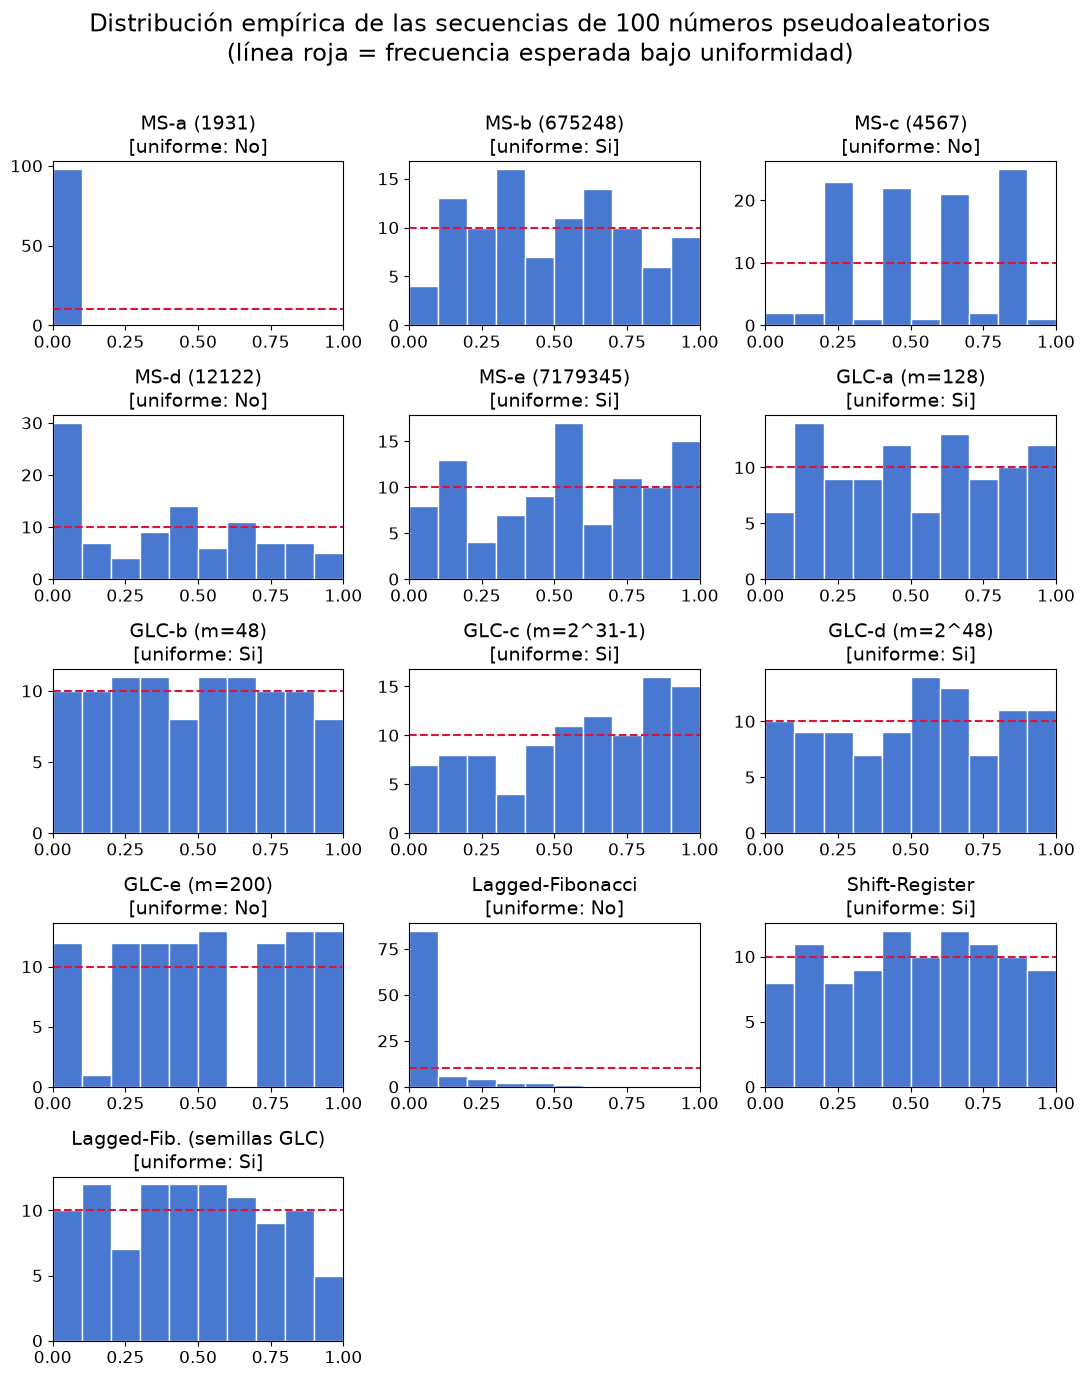

In [6]:
import matplotlib.pyplot as plt

# Histogramas de las 13 secuencias (n = 100, k = 10 clases)
nombres = list(secuencias.keys())
fig, axes = plt.subplots(5, 3, figsize=(11, 14))
for ax, nombre in zip(axes.ravel(), nombres):
    U = secuencias[nombre][1]
    ax.hist(U, bins=10, range=(0, 1), color='#4878CF', edgecolor='white')
    ax.axhline(len(U) / 10, color='crimson', ls='--', lw=1.5)
    ok = tabla_514.loc[tabla_514['Generador'] == nombre, 'Uniforme?'].iloc[0]
    ax.set_title(f'{nombre}\n[uniforme: {ok}]', fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.tick_params(labelsize=12)
for ax in axes.ravel()[len(nombres):]:
    ax.axis('off')
fig.suptitle('Distribución empírica de las secuencias de 100 números pseudoaleatorios\n'
             '(línea roja = frecuencia esperada bajo uniformidad)', fontsize=17)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
# 5.2. Uso de números aleatorios para evaluar integrales

Sea $\theta = \int_0^1 g(x)\,dx$. Si $U \sim \mathcal{U}(0,1)$ entonces $\theta = E[g(U)]$, y por la ley fuerte
de los grandes números

$$\hat\theta_n = \frac{1}{n}\sum_{i=1}^{n} g(u_i) \;\xrightarrow[n\to\infty]{}\; \theta$$

Este es el **método Monte Carlo** [Ross99, sec. 3.2]. Los cambios de variable usados para llevar cualquier
intervalo a $(0,1)$ son:

$$\int_a^b g(x)dx = \int_0^1 (b-a)\,g\big(a+(b-a)y\big)dy, \qquad
\int_0^\infty g(x)dx = \int_0^1 \frac{g\!\left(\tfrac{1}{y}-1\right)}{y^2}dy$$

Todos los $u_i$ provienen del **generador congruencial mixto** con $a=25214903917$, $c=11$, $m=2^{48}$, que fue
el que mejor se comportó en 5.1.4.

In [7]:
import numpy as np
import pandas as pd
from scipy import integrate

# Generador congruencial mixto "bueno" (el GLC-d de 5.1.2, periodo 2^48)
A_GLC, C_GLC, M_GLC = 25214903917, 11, 2 ** 48

def genranN(n, X0=2391, a=A_GLC, c=C_GLC, m=M_GLC):
    """n números pseudoaleatorios u_i ~ U(0,1) con el GLC mixto."""
    X = X0
    U = np.empty(n)
    for i in range(n):
        X = (a * X + c) % m
        U[i] = X / m
    return U

def monte_carlo(h, n=10_000, X0=2391, d=1):
    """Estimador de Monte Carlo: theta_hat = (1/n) * sum h(U_i).
    d = dimensión del integrando (número de U por réplica)."""
    U = genranN(n * d, X0=X0).reshape(n, d)
    valores = h(*[U[:, k] for k in range(d)])
    return valores.mean(), valores.std(ddof=1) / np.sqrt(n), valores

In [8]:
# --- Ejercicio 3:  theta = int_0^1 exp(e^x) dx ---------------------
h3 = lambda u: np.exp(np.exp(u))
exacto3 = integrate.quad(lambda x: np.exp(np.exp(x)), 0, 1)[0]

# --- Ejercicio 4:  theta = int_0^1 (1 - x^2)^{3/2} dx = 3*pi/16 ----
h4 = lambda u: (1 - u ** 2) ** 1.5
exacto4 = 3 * np.pi / 16

# --- Ejercicio 5:  theta = int_{-2}^{2} e^{x + x^2} dx -------------
#     y = (x + 2)/4  =>  x = -2 + 4y,  dx = 4 dy
def h5(u):
    x = -2 + 4 * u
    return 4 * np.exp(x + x ** 2)
exacto5 = integrate.quad(lambda x: np.exp(x + x ** 2), -2, 2)[0]

# --- Ejercicio 6:  theta = int_0^inf x (1 + x^2)^{-2} dx = 1/2 -----
#     y = 1/(x+1)  =>  x = 1/y - 1,  dx = dy / y^2
def h6(u):
    x = 1 / u - 1
    return x * (1 + x ** 2) ** -2 / u ** 2
exacto6 = 0.5

# --- Ejercicio 7:  theta = int_{-inf}^{inf} e^{-x^2} dx = sqrt(pi) -
#     por simetría = 2 * int_0^inf e^{-x^2} dx
def h7(u):
    x = 1 / u - 1
    return 2 * np.exp(-x ** 2) / u ** 2
exacto7 = np.sqrt(np.pi)

# --- Ejercicio 8:  theta = int_0^1 int_0^1 e^{(x+y)^2} dy dx -------
h8 = lambda u, v: np.exp((u + v) ** 2)
exacto8 = integrate.dblquad(lambda y, x: np.exp((x + y) ** 2), 0, 1,
                            lambda x: 0, lambda x: 1)[0]

# --- Ejercicio 9:  theta = int_0^inf int_0^x e^{-(x+y)} dy dx = 1/2 -
#     Sugerencia de [Ross99]: usar I(y < x) para llevar el dominio a (0,inf)^2
def h9(u, v):
    x = 1 / u - 1
    y = 1 / v - 1
    return np.exp(-(x + y)) * (y < x) / (u ** 2 * v ** 2)
exacto9 = 0.5

ejercicios = [
    ('3', 'int_0^1 e^{e^x} dx',                  h3, 1, exacto3, 'no elemental'),
    ('4', 'int_0^1 (1-x^2)^{3/2} dx',            h4, 1, exacto4, '3*pi/16'),
    ('5', 'int_{-2}^{2} e^{x+x^2} dx',           h5, 1, exacto5, 'no elemental'),
    ('6', 'int_0^inf x(1+x^2)^{-2} dx',          h6, 1, exacto6, '1/2'),
    ('7', 'int_{-inf}^{inf} e^{-x^2} dx',        h7, 1, exacto7, 'sqrt(pi)'),
    ('8', 'int_0^1 int_0^1 e^{(x+y)^2} dy dx',   h8, 2, exacto8, 'no elemental'),
    ('9', 'int_0^inf int_0^x e^{-(x+y)} dy dx',  h9, 2, exacto9, '1/2'),
]

n_mc = 10_000
filas, muestras = [], {}
for k, (num, expr, h, d, exacto, forma) in enumerate(ejercicios):
    est, ee, vals = monte_carlo(h, n=n_mc, X0=2391 + 1000 * k, d=d)
    muestras[num] = vals
    filas.append({
        'Ej.': num,
        'Integral': expr,
        'Estimacion MC': round(est, 4),
        'Error est.': round(ee, 4),
        'IC 95%': f'({est - 1.96 * ee:.4f}, {est + 1.96 * ee:.4f})',
        'Valor exacto': round(exacto, 4),
        'Forma cerrada': forma,
        'Error abs.': round(abs(est - exacto), 4),
        'Error rel. %': round(100 * abs(est - exacto) / abs(exacto), 2),
    })

tabla_52 = pd.DataFrame(filas)
tabla_52

,Ej.,Integral,Estimacion MC,Error est.,IC 95%,Valor exacto,Forma cerrada,Error abs.,Error rel. %
0,3,int_0^1 e^{e^x} dx,6.3182,0.0328,"(6.2540, 6.3825)",6.3166,no elemental,0.0017,0.03
1,4,int_0^1 (1-x^2)^{3/2} dx,0.5858,0.0033,"(0.5793, 0.5923)",0.5890,3*pi/16,0.0032,0.55
2,5,int_{-2}^{2} e^{x+x^2} dx,93.9143,2.4627,"(89.0874, 98.7413)",93.1628,no elemental,0.7516,0.81
3,6,int_0^inf x(1+x^2)^{-2} dx,0.5038,0.0034,"(0.4972, 0.5104)",0.5000,1/2,0.0038,0.76
4,7,int_{-inf}^{inf} e^{-x^2} dx,1.7839,0.0141,"(1.7562, 1.8116)",1.7725,sqrt(pi),0.0115,0.65
5,8,int_0^1 int_0^1 e^{(x+y)^2} dy dx,4.9210,0.0599,"(4.8036, 5.0384)",4.8992,no elemental,0.0219,0.45
6,9,int_0^inf int_0^x e^{-(x+y)} dy dx,0.5040,0.0073,"(0.4897, 0.5183)",0.5000,1/2,0.0040,0.81


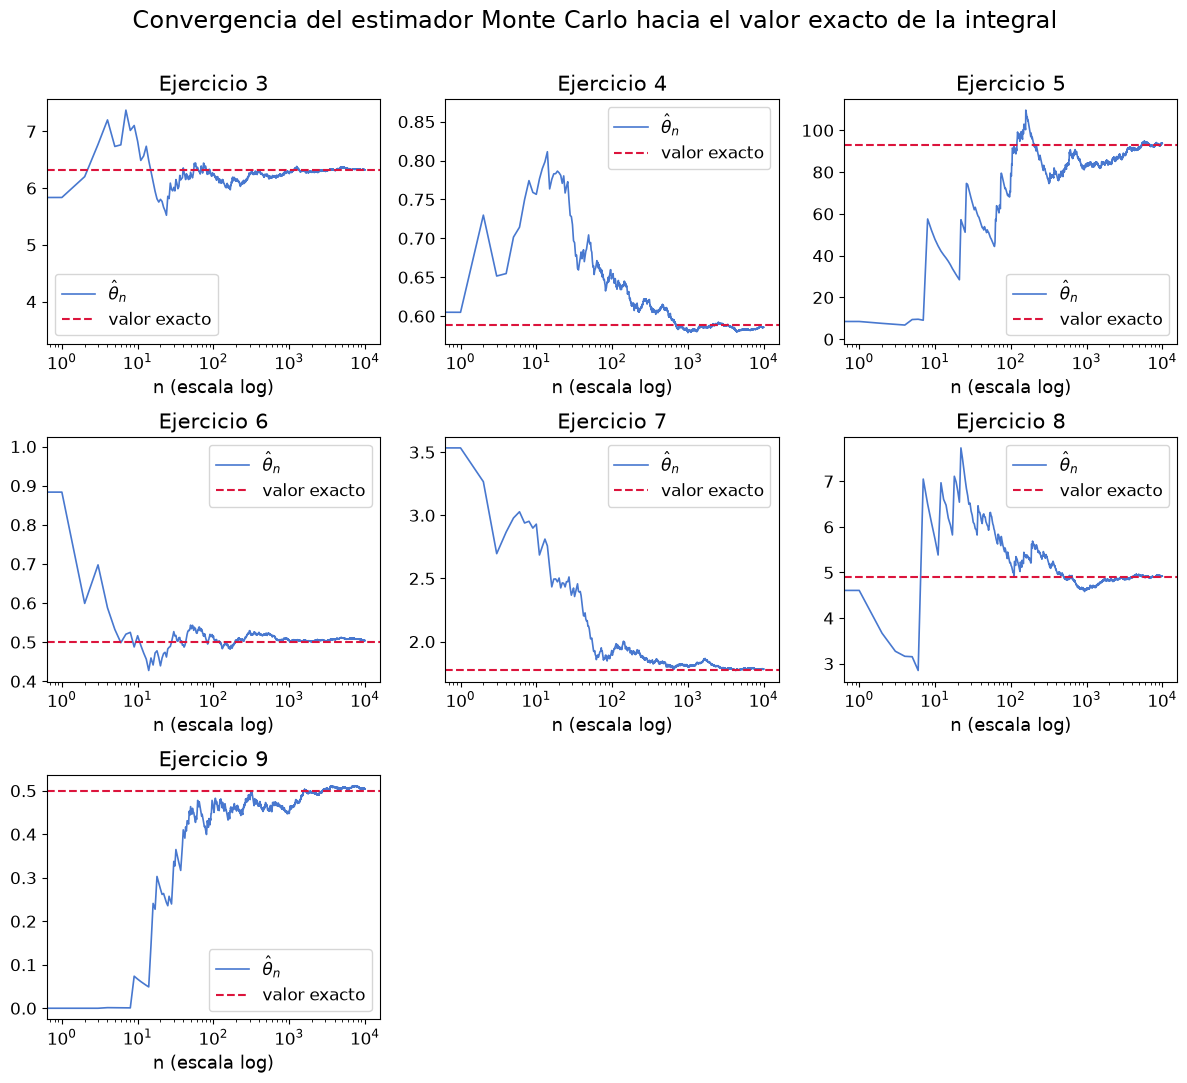

In [9]:
import matplotlib.pyplot as plt

# Convergencia del estimador conforme crece n
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
for ax, (num, expr, h, d, exacto, forma) in zip(axes.ravel(), ejercicios):
    vals = muestras[num]
    corrida = np.cumsum(vals) / np.arange(1, len(vals) + 1)
    ax.plot(corrida, lw=1.2, color='#4878CF', label=r'$\hat\theta_n$')
    ax.axhline(exacto, color='crimson', ls='--', lw=1.5, label='valor exacto')
    ax.set_xscale('log')
    ax.set_title(f'Ejercicio {num}', fontsize=15)
    ax.set_xlabel('n (escala log)', fontsize=13)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=12)
for ax in axes.ravel()[len(ejercicios):]:
    ax.axis('off')
fig.suptitle('Convergencia del estimador Monte Carlo hacia el valor exacto de la integral', fontsize=17)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Las siete estimaciones caen dentro del $1\,\%$ del valor exacto con $n = 10{,}000$ réplicas, y en todos los
casos el intervalo de confianza al $95\,\%$ contiene el valor verdadero. Las gráficas muestran el
comportamiento característico del método: el error decrece como $\sigma/\sqrt{n}$, es decir, **para ganar un
dígito de precisión hay que multiplicar $n$ por 100**. El ejercicio 5 es el de mayor error relativo porque
$e^{x+x^2}$ crece hasta $\approx e^{6}$ en $x=2$ y su varianza es enorme; los ejercicios 6 y 9, con soporte
infinito, tienen colas que el cambio de variable comprime cerca de $u \to 0$ y también elevan la varianza.

---
# 5.3. Generación de variables aleatorias discretas

**Método de la transformada inversa** [Ross99, sec. 4.1]: para una v.a. discreta con masa
$p_j = P\{X = x_j\}$ se genera $U \sim \mathcal{U}(0,1)$ y se hace

$$X = x_j \quad \text{si} \quad \sum_{i<j} p_i \le U < \sum_{i\le j} p_i$$

Todos los apartados usan el generador congruencial mixto exigido por la guía:
$X_0 = 2391$, $a = 25214903917$, $c = 11$, $m = 2^{48}$.

In [10]:
import numpy as np
import pandas as pd
from scipy import stats

# Generador congruencial mixto exigido por la guía para el punto 5.3
X0_53, A_53, C_53, M_53 = 2391, 25214903917, 11, 2 ** 48

def genranN53(n, X0=X0_53, a=A_53, c=C_53, m=M_53):
    X = X0
    U = np.empty(n)
    for i in range(n):
        X = (a * X + c) % m
        U[i] = X / m
    return U

def transformada_inversa(U, X, p):
    """Método de la transformada inversa discreta [Ross99, sec. 4.1]."""
    F = np.cumsum(p)
    V = []
    for u in U:
        for j in range(len(X)):
            if u < F[j]:
                V.append(X[j])
                break
    return np.array(V)

def comparar(V, X, p):
    """Tabla de frecuencias teóricas vs empíricas."""
    n = len(V)
    obs = np.array([int(np.sum(V == x)) for x in X])
    return pd.DataFrame({
        'X = j': X,
        'p_j teorica': p,
        'Frec. esperada': np.round(np.array(p) * n, 2),
        'Frec. observada': obs,
        'Frec. relativa': np.round(obs / n, 4),
    })

## 5.3 (a) $p_1=0.20,\;p_2=0.15,\;p_3=0.25,\;p_4=0.40$

In [11]:
X_a = [1, 2, 3, 4]
p_a = [0.20, 0.15, 0.25, 0.40]

U_a = genranN53(100)
V_a = transformada_inversa(U_a, X_a, p_a)

print('Primeros 100 valores generados:')
print(list(map(int, V_a)))
comparar(V_a, X_a, p_a)

Primeros 100 valores generados:
[2, 4, 4, 4, 4, 3, 4, 4, 3, 4, 2, 1, 4, 4, 1, 1, 1, 1, 2, 3, 4, 3, 1, 3, 2, 4, 3, 4, 1, 3, 4, 2, 4, 2, 1, 4, 4, 1, 4, 4, 4, 1, 2, 1, 4, 3, 2, 3, 4, 2, 4, 3, 3, 3, 4, 4, 4, 2, 4, 2, 1, 4, 3, 3, 3, 3, 4, 1, 4, 4, 1, 3, 1, 4, 4, 3, 2, 1, 4, 4, 2, 1, 3, 1, 4, 3, 3, 3, 4, 3, 3, 1, 1, 3, 2, 4, 3, 4, 1, 3]


,X = j,p_j teorica,Frec. esperada,Frec. observada,Frec. relativa
0,1,0.20,20.0,21,0.21
1,2,0.15,15.0,14,0.14
2,3,0.25,25.0,27,0.27
3,4,0.40,40.0,38,0.38


## 5.3 (b) $P\{X=1\}=0.3,\;P\{X=2\}=0.2,\;P\{X=3\}=0.35,\;P\{X=4\}=0.15$

[Ross99] señala en la observación 2 de la sección 4.1 que conviene recorrer los valores en **orden decreciente
de $p_j$**, porque el tiempo del algoritmo es proporcional al número de intervalos examinados. El orden
eficiente aquí es $3\,(0.35) \to 1\,(0.30) \to 2\,(0.20) \to 4\,(0.15)$.

In [12]:
X_b = [1, 2, 3, 4]
p_b = [0.30, 0.20, 0.35, 0.15]

# orden decreciente de p_j -> algoritmo eficiente
orden = np.argsort(p_b)[::-1]
X_b_ord = [X_b[i] for i in orden]
p_b_ord = [p_b[i] for i in orden]
print('Orden eficiente:', X_b_ord, ' con p_j =', p_b_ord)

U_b = genranN53(100)
V_b = transformada_inversa(U_b, X_b_ord, p_b_ord)

# número medio de comparaciones de cada versión
comp_ing = sum((i + 1) * p for i, p in enumerate(p_b))
comp_efi = sum((i + 1) * p for i, p in enumerate(p_b_ord))
print(f'Comparaciones promedio -> orden natural: {comp_ing:.3f}   orden eficiente: {comp_efi:.3f}')

print()
print('Primeros 100 valores generados:')
print(list(map(int, V_b)))
comparar(V_b, X_b, p_b)

Orden eficiente: [3, 1, 2, 4]  con p_j = [0.35, 0.3, 0.2, 0.15]
Comparaciones promedio -> orden natural: 2.350   orden eficiente: 2.150

Primeros 100 valores generados:
[3, 2, 2, 2, 2, 1, 2, 4, 1, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 1, 1, 1, 3, 1, 3, 4, 1, 4, 3, 1, 2, 3, 4, 3, 3, 2, 4, 3, 2, 1, 4, 3, 3, 3, 4, 1, 3, 1, 2, 3, 4, 1, 1, 1, 2, 4, 4, 3, 2, 3, 3, 2, 1, 1, 1, 1, 2, 3, 4, 4, 3, 1, 3, 4, 4, 1, 3, 3, 2, 1, 3, 3, 1, 3, 4, 1, 1, 1, 4, 1, 1, 3, 3, 1, 3, 2, 1, 4, 3, 1]


,X = j,p_j teorica,Frec. esperada,Frec. observada,Frec. relativa
0,1,0.30,30.0,30,0.30
1,2,0.20,20.0,18,0.18
2,3,0.35,35.0,35,0.35
3,4,0.15,15.0,17,0.17


## 5.3 (c) $p_1 = 1/3,\; p_2 = 2/3$ con $n = 100,\,1000,\,10000$

Se determina la proporción de valores iguales a 1 y se compara con $p_1 = 1/3$ y con el error estándar teórico
$\sqrt{p_1(1-p_1)/n}$.

In [13]:
X_c = [1, 2]
p_c = [1 / 3, 2 / 3]

filas_c = []
for n in [100, 1000, 10000]:
    V = transformada_inversa(genranN53(n), X_c, p_c)
    prop = np.mean(V == 1)
    ee = np.sqrt(p_c[0] * (1 - p_c[0]) / n)
    filas_c.append({'n': n,
                    'N(X=1)': int(np.sum(V == 1)),
                    'Proporcion de unos': round(prop, 4),
                    'p1 teorica': round(p_c[0], 4),
                    'Error abs.': round(abs(prop - p_c[0]), 4),
                    'Error est. teorico': round(ee, 4)})

tabla_53c = pd.DataFrame(filas_c)
tabla_53c

,n,N(X=1),Proporcion de unos,p1 teorica,Error abs.,Error est. teorico
0,100,34,0.3400,0.3333,0.0067,0.0471
1,1000,328,0.3280,0.3333,0.0053,0.0149
2,10000,3316,0.3316,0.3333,0.0017,0.0047


## 5.3 (d) Método de composición

$X$ toma los valores $1,\dots,10$ con probabilidades $0.06,0.06,0.06,0.06,0.06,0.15,0.13,0.14,0.15,0.13$.

Siguiendo [Ross99, sec. 4.5] se escribe $p_j = \alpha\,q_j + (1-\alpha)\,r_j$, con $q$ **uniforme discreta en
$1..10$** ($q_j = 1/10$):

* Para $j \le 5$: $\;0.06 = \alpha/10 \;\Rightarrow\; \boxed{\alpha = 0.6}$ y $r_j = 0$.
* Para $j \ge 6$: $\;r_j = \dfrac{p_j - 0.06}{0.4}$, es decir
  $r_6 = 0.225,\; r_7 = 0.175,\; r_8 = 0.200,\; r_9 = 0.225,\; r_{10} = 0.175$ (suman 1).

**Algoritmo**

> PASO 1: Generar $U_1$ y $U_2$.
> PASO 2: Si $U_1 < 0.6$, hacer $X = \text{Ent}(10\,U_2) + 1$ y terminar.
> PASO 3: En caso contrario, obtener $X \in \{6,\dots,10\}$ por transformada inversa sobre $r_j$ con $U_2$.

La ventaja es que en el 60 % de los casos $X$ se resuelve con una sola multiplicación (uniforme discreta), sin
recorrer intervalos.

In [14]:
X_d = list(range(1, 11))
p_d = [0.06, 0.06, 0.06, 0.06, 0.06, 0.15, 0.13, 0.14, 0.15, 0.13]

alpha_d = 0.6
r_d = [(p - 0.06) / (1 - alpha_d) for p in p_d[5:]]      # sobre j = 6..10
print('alpha =', alpha_d)
print('r_j (j=6..10) =', [round(r, 4) for r in r_d], ' suma =', round(sum(r_d), 6))

def genera_composicion(n, X0=X0_53):
    U = genranN53(2 * n, X0=X0).reshape(n, 2)
    F_r = np.cumsum(r_d)
    V = []
    for u1, u2 in U:
        if u1 < alpha_d:
            V.append(int(10 * u2) + 1)          # uniforme discreta en 1..10
        else:
            for j in range(5):
                if u2 < F_r[j]:
                    V.append(6 + j)
                    break
    return np.array(V)

V_d = genera_composicion(10_000)
print()
print('Primeros 20 valores:', list(map(int, V_d[:20])))

obs_d = np.array([int(np.sum(V_d == x)) for x in X_d])
chi_d = stats.chisquare(obs_d, np.array(p_d) * len(V_d))
print(f'Bondad de ajuste chi2 = {chi_d.statistic:.3f}   p-valor = {chi_d.pvalue:.4f}')

comparar(V_d, X_d, p_d)

alpha = 0.6
r_j (j=6..10) = [0.225, 0.175, 0.2, 0.225, 0.175]  suma = 1.0

Primeros 20 valores: [8, 9, 7, 10, 8, 1, 9, 2, 2, 5, 8, 4, 10, 10, 6, 7, 7, 7, 6, 9]
Bondad de ajuste chi2 = 9.817   p-valor = 0.3655


,X = j,p_j teorica,Frec. esperada,Frec. observada,Frec. relativa
0,1,0.06,600.0,577,0.0577
1,2,0.06,600.0,627,0.0627
2,3,0.06,600.0,586,0.0586
3,4,0.06,600.0,561,0.0561
4,5,0.06,600.0,623,0.0623
5,6,0.15,1500.0,1526,0.1526
6,7,0.13,1300.0,1274,0.1274
7,8,0.14,1400.0,1402,0.1402
8,9,0.15,1500.0,1557,0.1557
9,10,0.13,1300.0,1267,0.1267


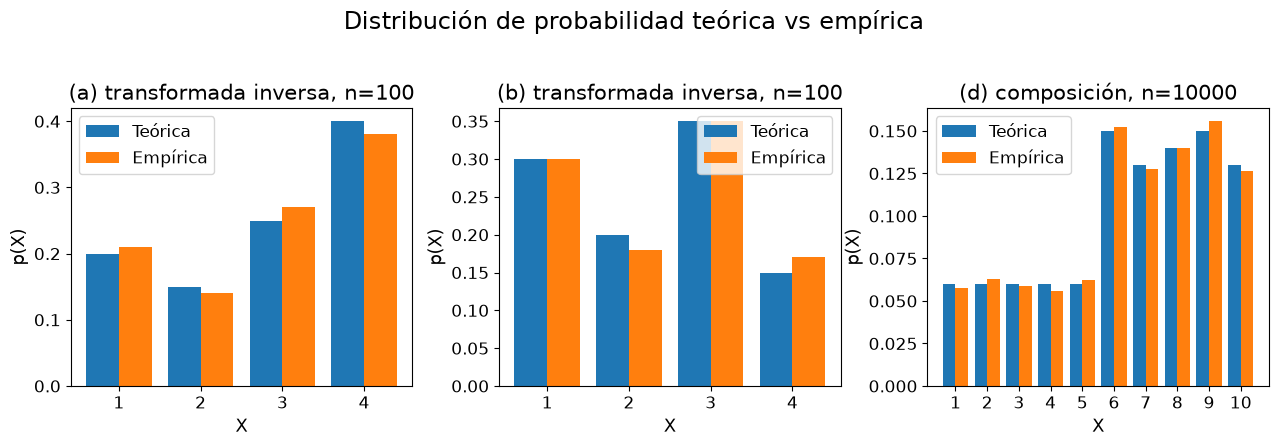

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (V, X, p, titulo) in zip(axes, [
        (V_a, X_a, p_a, '(a) transformada inversa, n=100'),
        (V_b, X_b, p_b, '(b) transformada inversa, n=100'),
        (V_d, X_d, p_d, '(d) composición, n=10000')]):
    n = len(V)
    obs = np.array([np.sum(V == x) for x in X]) / n
    w = 0.4
    ax.bar(np.array(X) - w / 2, p, width=w, label='Teórica')
    ax.bar(np.array(X) + w / 2, obs, width=w, label='Empírica')
    ax.set_title(titulo, fontsize=15)
    ax.set_xlabel('X', fontsize=13); ax.set_ylabel('p(X)', fontsize=13)
    ax.set_xticks(X)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=12)
fig.suptitle('Distribución de probabilidad teórica vs empírica', fontsize=17)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

---
# 5.4. Simulación *ad hoc* con generación de variables aleatorias discretas

Se repite la simulación del **Laboratorio 1** (secciones 5.1 y 5.2: sistema de cola con un servidor y 20
clientes) pero sustituyendo los dados por generadores propios:

* **Tiempos entre llegadas** $\sim$ Poisson($\lambda = 10$), algoritmo de [Ross99, sec. 4.2]:
  $p_0 = e^{-\lambda}$, $p_{i+1} = \frac{\lambda}{i+1}p_i$.
* **Tiempos de servicio** $\sim$ Binomial($n = 10$, $p = 0.40$), algoritmo de [Ross99, sec. 4.3]:
  $p_0 = (1-p)^n$, $p_{i+1} = \frac{n-i}{i+1}\frac{p}{1-p}\,p_i$.

Igual que en el Laboratorio 1, cada variable aleatoria usa un **flujo independiente** de números
pseudoaleatorios (dos semillas distintas del mismo GLC).

In [16]:
import numpy as np
import pandas as pd

A_GLC, C_GLC, M_GLC = 25214903917, 11, 2 ** 48

def genranN54(n, X0, a=A_GLC, c=C_GLC, m=M_GLC):
    X = X0
    U = np.empty(n)
    for i in range(n):
        X = (a * X + c) % m
        U[i] = X / m
    return U

# --- v.a. Poisson  [Ross99, sec. 4.2] ------------------------------
#   PASO 2: i=0, p=e^{-lambda}, F=p
#   PASO 3: si U < F -> X = i
#   PASO 4: p = lambda*p/(i+1), F = F+p, i = i+1
def genpoisson(u, lam):
    i, p = 0, np.exp(-lam)
    F = p
    while u >= F:
        p = lam * p / (i + 1)
        F += p
        i += 1
    return i

# --- v.a. Binomial  [Ross99, sec. 4.3] -----------------------------
#   PASO 2: c=p/(1-p), i=0, pr=(1-p)^n, F=pr
#   PASO 4: pr = [c(n-i)/(i+1)]pr, F = F+pr, i = i+1
def genbinomial(u, n, p):
    c = p / (1 - p)
    i, pr = 0, (1 - p) ** n
    F = pr
    while u >= F:
        pr = c * (n - i) / (i + 1) * pr
        F += pr
        i += 1
    return i

LAMBDA = 10                 # tiempos entre llegadas ~ Poisson(10)
N_BIN, P_BIN = 10, 0.40     # tiempos de servicio  ~ Binomial(10, 0.40)
N_CLIENTES = 20

In [17]:
def simular_banco(n_clientes=N_CLIENTES, X0_lleg=2391, X0_serv=5033):
    U_lleg = genranN54(n_clientes, X0_lleg)
    U_serv = genranN54(n_clientes, X0_serv)

    tba = [genpoisson(u, LAMBDA) for u in U_lleg]
    tba[0] = 0                                   # el 1er cliente llega en t = 0
    servicio = [genbinomial(u, N_BIN, P_BIN) for u in U_serv]

    llegada, inicio, fin = [], [], []
    ocioso, sistema, cola = [], [], []
    t_llegada, fin_ant = 0, 0
    for i in range(n_clientes):
        t_llegada += tba[i]
        ini = max(t_llegada, fin_ant)            # el servidor atiende cuando puede
        f = ini + servicio[i]
        llegada.append(t_llegada); inicio.append(ini); fin.append(f)
        ocioso.append(max(0, t_llegada - fin_ant))
        cola.append(ini - t_llegada)
        sistema.append(f - t_llegada)
        fin_ant = f

    df = pd.DataFrame({
        'Customer': range(1, n_clientes + 1),
        'Time Between Arrivals': tba,
        'Arrival Time': llegada,
        'Service Time': servicio,
        'Service Begins': inicio,
        'Service Ends': fin,
        'Time in System': sistema,
        'Idle Time': ocioso,
        'Time in Queue': cola,
    })

    T = fin[-1]
    n_espera = sum(1 for q in cola if q > 0)
    medidas = {
        'Average time in system': sum(sistema) / n_clientes,
        'Percent idle time': 100 * sum(ocioso) / T,
        'Average waiting time per customer': sum(cola) / n_clientes,
        'Fraction having to wait': n_espera / n_clientes,
        'Average waiting time of those who waited':
            (sum(cola) / n_espera) if n_espera else 0.0,
    }
    return df, medidas

tabla_54, medidas_54 = simular_banco()
tabla_54

,Customer,Time Between Arrivals,Arrival Time,Service Time,Service Begins,Service Ends,Time in System,Idle Time,Time in Queue
0,1,0,0,4,0,4,4,0,0
1,2,12,12,7,12,19,7,8,0
2,3,11,23,5,23,28,5,4,0
3,4,12,35,3,35,38,3,7,0
4,5,12,47,2,47,49,2,9,0
5,6,9,56,3,56,59,3,7,0
6,7,11,67,6,67,73,6,8,0
7,8,14,81,3,81,84,3,8,0
8,9,9,90,3,90,93,3,6,0
9,10,12,102,5,102,107,5,9,0


In [18]:
print('TOTALES  ->  Time in System: %d    Idle Time: %d    Time in Queue: %d    T final: %d'
      % (tabla_54['Time in System'].sum(), tabla_54['Idle Time'].sum(),
         tabla_54['Time in Queue'].sum(), tabla_54['Service Ends'].iloc[-1]))
print()
print('MEDIDAS DE DESEMPEÑO (20 clientes)')
for k, v in medidas_54.items():
    print(f'  {k:<45s} {v:.4f}')
print()
print('E[TBA] teórico = %.2f    observado = %.2f' % (LAMBDA, np.mean(tabla_54['Time Between Arrivals'][1:])))
print('E[ST]  teórico = %.2f    observado = %.2f' % (N_BIN * P_BIN, np.mean(tabla_54['Service Time'])))
print('Factor de utilización rho = E[ST]/E[TBA] = %.3f' % (N_BIN * P_BIN / LAMBDA))

TOTALES  ->  Time in System: 82    Idle Time: 102    Time in Queue: 0    T final: 184

MEDIDAS DE DESEMPEÑO (20 clientes)
  Average time in system                        4.1000
  Percent idle time                             55.4348
  Average waiting time per customer             0.0000
  Fraction having to wait                       0.0000
  Average waiting time of those who waited      0.0000

E[TBA] teórico = 10.00    observado = 9.47
E[ST]  teórico = 4.00    observado = 4.10
Factor de utilización rho = E[ST]/E[TBA] = 0.400


Como una sola corrida de 20 clientes es muy sensible al azar (conclusión del Laboratorio 1), se repite la
simulación **10 veces** con semillas distintas para verificar que lo observado es estructural y no casualidad.

In [19]:
filas_runs = []
for r in range(10):
    _, med = simular_banco(20, X0_lleg=2391 + 7919 * r, X0_serv=5033 + 104729 * r)
    filas_runs.append({'Run': r + 1, **{k: round(v, 4) for k, v in med.items()}})

tabla_54_runs = pd.DataFrame(filas_runs)
print(tabla_54_runs.to_string(index=False))
print()
print('PROMEDIO DE LAS 10 CORRIDAS')
print(tabla_54_runs.drop(columns='Run').mean().round(4).to_string())

 Run  Average time in system  Percent idle time  Average waiting time per customer  Fraction having to wait  Average waiting time of those who waited
   1                    4.10            55.4348                               0.00                     0.00                                       0.0
   2                    4.25            55.7292                               0.00                     0.00                                       0.0
   3                    3.50            66.1836                               0.00                     0.00                                       0.0
   4                    4.15            56.6138                               0.05                     0.05                                       1.0
   5                    4.90            51.5152                               0.10                     0.10                                       1.0
   6                    4.05            59.9010                               0.00                  

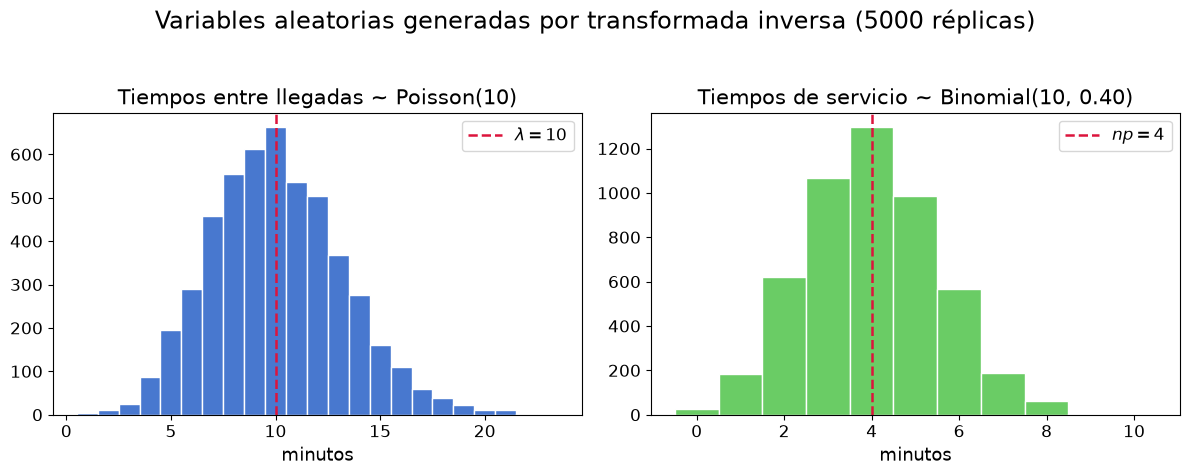

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# distribucion de los tiempos generados sobre muchas replicas
U1 = genranN54(5000, 2391)
U2 = genranN54(5000, 5033)
poi = [genpoisson(u, LAMBDA) for u in U1]
bino = [genbinomial(u, N_BIN, P_BIN) for u in U2]

axes[0].hist(poi, bins=range(min(poi), max(poi) + 2), align='left',
             color='#4878CF', edgecolor='white')
axes[0].axvline(LAMBDA, color='crimson', ls='--', lw=1.8, label=r'$\lambda=10$')
axes[0].set_title('Tiempos entre llegadas ~ Poisson(10)', fontsize=15)
axes[0].set_xlabel('minutos', fontsize=13); axes[0].legend(fontsize=12)
axes[0].tick_params(labelsize=12)

axes[1].hist(bino, bins=range(0, N_BIN + 2), align='left',
             color='#6ACC65', edgecolor='white')
axes[1].axvline(N_BIN * P_BIN, color='crimson', ls='--', lw=1.8, label=r'$np=4$')
axes[1].set_title('Tiempos de servicio ~ Binomial(10, 0.40)', fontsize=15)
axes[1].set_xlabel('minutos', fontsize=13); axes[1].legend(fontsize=12)
axes[1].tick_params(labelsize=12)

fig.suptitle('Variables aleatorias generadas por transformada inversa (5000 réplicas)', fontsize=17)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

---
## Fin del laboratorio

Todos los generadores (MidSquare, congruencial mixto, Lagged-Fibonacci, Shift-Register), las pruebas de ciclo,
uniformidad y aleatoriedad, la integración Monte Carlo y los generadores de variables aleatorias discretas
(transformada inversa, Poisson, Binomial y composición) fueron implementados desde cero; la única función
externa de aleatoriedad usada es la del propio generador congruencial mixto. `scipy.stats` se usó únicamente
para los valores críticos y `scipy.integrate` como referencia de comparación en 5.2.